In [1]:
import pandas as pd
import os
import numpy as np

# --------------------------------------------------
# Paths
# --------------------------------------------------
CURRENT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(CURRENT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
CW_DIR_PATH = os.path.join(DATA_DIR_PATH, "cw")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")

# --------------------------------------------------
# Load data
# --------------------------------------------------
iea = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policies_clean.csv"))

# --------------------------------------------------
# Basic preprocessing
# --------------------------------------------------
iea["status"] = iea["status"].str.lower()
iea["year"] = iea["year"].astype(int)

iea["full_text"] = (
    iea["title"].fillna("") + " " + iea["description"].fillna("")
).str.lower()

max_year = iea["year"].max()

# --------------------------------------------------
# Expand in-force policies to all active years
# --------------------------------------------------
expanded_rows = []

for _, row in iea.iterrows():
    if row["status"] == "in force":
        for y in range(int(row["year"]), int(max_year) + 1):
            r = row.copy()
            r["year"] = y
            expanded_rows.append(r)
    elif row["status"] == "ended":
        expanded_rows.append(row)


iea = (
    pd.DataFrame(expanded_rows)
    .sort_values(["iso_alpha_3", "year"])
    .reset_index(drop=True)
)

# --------------------------------------------------
# Jurisdiction weights
# --------------------------------------------------

print("IEA jurisdictions:", iea.jurisdiction.unique())

jurisdiction_weights = {
    "National": 1.00,         # nationwide coverage
    "State/Provincial": 0.60, # substantial but partial coverage
    "Regional": 0.60,         # multi-state/region coverage but not nationwide
    "City/Municipal": 0.35,   # localized coverage; often important but narrow
    "International": 0.25,    # indirect unless transposed/enforced domestically
    "Other": 0.40,            # ambiguous scope; assign mid-low conservative value
    "Unknown": 0.40
}


iea["w_jurisdiction"] = (
    iea["jurisdiction"]
    .map(jurisdiction_weights)
    .fillna(0.5)
)

# --------------------------------------------------
# NLP-based policy stringency score
# --------------------------------------------------
keywords = {
    "C1": [
        "ban", "banned", "prohibit", "mandatory", "phase-out",
        "elimination", "forbidden", "outlawed"
    ],
    "C2": [
        "tax", "levy", "pricing", "carbon pricing", "tariff"
    ],
    "C3": [
        "standard", "performance", "emissions limit",
        "minimum standard", "compliance"
    ],
    "C4": [
        "subsidy", "grant", "funding", "finance", "support",
        "research", "development", "training", "information",
        "awareness", "pilot"
    ]
}

nlp_weight_map = {
    "C1": 1.0,
    "C2": 0.75,
    "C3": 0.5,
    "C4": 0.25
}

def nlp_score(text):
    text = str(text).lower()
    for level, words in keywords.items():
        if any(w in text for w in words):
            return nlp_weight_map[level]
    return 0.25  # conservative default

iea["w_nlp"] = iea["full_text"].apply(nlp_score)

# --------------------------------------------------
# Combined weight (jurisdiction × NLP)
# --------------------------------------------------
iea["w_jur_nlp"] = iea["w_jurisdiction"] * iea["w_nlp"]

# --------------------------------------------------
# Aggregate to country–year (FLOWS)
# --------------------------------------------------
policy_year = (
    iea
    .groupby(["iso_alpha_3", "year"])
    .agg(
        policy_flow_raw=("iso_alpha_3", "size"),
        policy_flow_jur=("w_jurisdiction", "sum"),
        policy_flow_jur_nlp=("w_jur_nlp", "sum")
    )
    .reset_index()
    .sort_values(["iso_alpha_3", "year"])
)

# --------------------------------------------------
# Convert FLOWS → STOCKS (cumulative)
# --------------------------------------------------
for col in [
    "policy_flow_raw",
    "policy_flow_jur",
    "policy_flow_jur_nlp"
]:
    policy_year[f"{col}_stock"] = (
        policy_year
        .groupby("iso_alpha_3")[col]
        .cumsum()
    )

# # --------------------------------------------------
# # Optional log transforms (useful for ML)
# # --------------------------------------------------
# policy_year["log_policy_stock_raw"] = np.log1p(policy_year["policy_flow_raw_stock"])
# policy_year["log_policy_stock_jur"] = np.log1p(policy_year["policy_flow_jur_stock"])
# policy_year["log_policy_stock_jur_nlp"] = np.log1p(policy_year["policy_flow_jur_nlp_stock"])

# --------------------------------------------------
# Final output
# --------------------------------------------------
policy_indices = policy_year[
    [
        "iso_alpha_3",
        "year",
        "policy_flow_raw_stock",
        "policy_flow_jur_stock",
        "policy_flow_jur_nlp_stock",
        # "log_policy_stock_raw",
        # "log_policy_stock_jur",
        # "log_policy_stock_jur_nlp"
    ]
]

policy_indices.head()

IEA jurisdictions: ['International' 'National' 'State/Provincial' 'City/Municipal' 'Regional'
 'Unknown' 'Other']


,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock
0,AFG,1971,1,0.25,0.1875
1,AFG,1972,2,0.50,0.3750
2,AFG,1973,3,0.75,0.5625
3,AFG,1974,4,1.00,0.7500
4,AFG,1975,5,1.25,0.9375


In [2]:
import matplotlib.pyplot as plt

def plot_policy_stocks(policy_df, iso3):
    """
    Plot policy stock time series for a given ISO3 country code.

    Parameters
    ----------
    policy_df : pd.DataFrame
        DataFrame containing policy stock variables with columns:
        - iso_alpha_3
        - year
        - policy_flow_raw_stock
        - policy_flow_jur_stock
        - policy_flow_jur_nlp_stock

    iso3 : str
        ISO alpha-3 country code (e.g. 'DEU', 'MEX', 'USA')
    """

    df = (
        policy_df[policy_df["iso_alpha_3"] == iso3]
        .sort_values("year")
    )

    if df.empty:
        raise ValueError(f"No data found for ISO3 code: {iso3}")

    plt.figure(figsize=(10, 6))

    plt.plot(
        df["year"],
        df["policy_flow_raw_stock"],
        label="Raw policy stock",
        linewidth=2
    )

    plt.plot(
        df["year"],
        df["policy_flow_jur_stock"],
        label="Jurisdiction-weighted stock",
        linewidth=2
    )

    plt.plot(
        df["year"],
        df["policy_flow_jur_nlp_stock"],
        label="Jurisdiction + NLP weighted stock",
        linewidth=2
    )

    plt.xlabel("Year")
    plt.ylabel("Policy stock (cumulative)")
    plt.title(f"Climate policy stock over time – {iso3}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


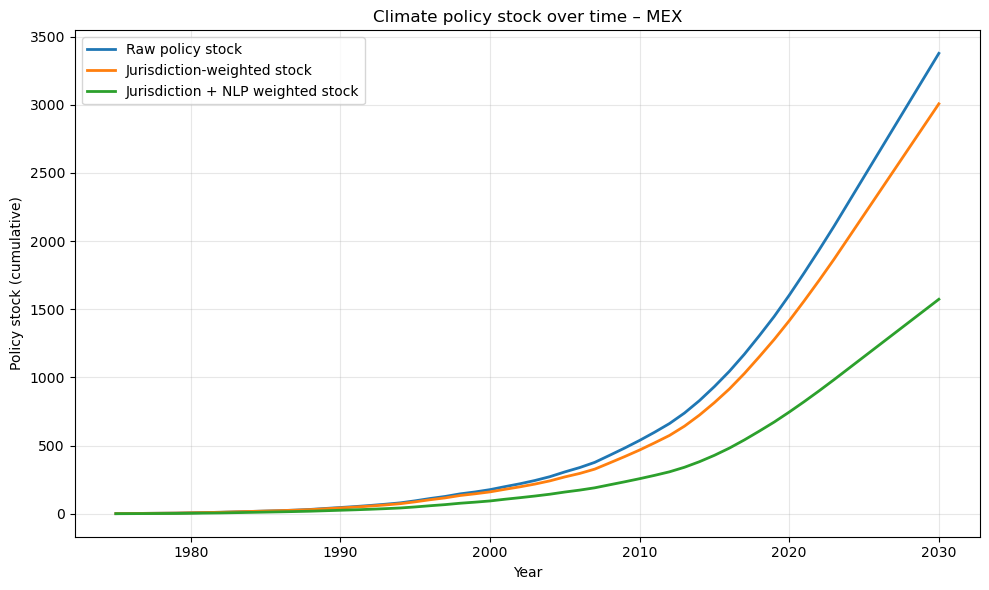

In [3]:
plot_policy_stocks(policy_indices, "MEX")

In [4]:
policy_indices.to_csv(
    os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_indices.csv"),
    index=False
)